# Analise do Payroll - Employment Situation Report

Este notebook reproduz a analise do relatorio de emprego dos EUA (Nonfarm Payrolls).

**Fonte dos Dados:**
- Bloomberg Terminal (NFP TCH, USURTOT, AHE MOM%, AHE YOY%, PRUSTOT)
- Bureau of Labor Statistics: https://www.bls.gov/news.release/empsit.b.htm

In [15]:
# Configuracao do ambiente
import sys
from pathlib import Path

# Adiciona o diretorio raiz ao path (4 niveis: notebooks -> payroll -> reports -> src -> root)
project_root = Path.cwd().parents[3]
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Configuracao de estilo
from classes.config import COPOM, FIGSIZE, DPI, plot_config, clean_axes

plot_config(6)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# ============================================
# CONFIGURACAO: Data inicial para graficos
# ============================================
# Altere esta data para mostrar mais ou menos historico nos graficos.
# Os dados completos desde 1990 estarao disponiveis para analise.
PLOT_START_DATE = '2022-01-01'
# ============================================

In [16]:
# Importa os modulos do payroll
from reports.payroll.core.data_loader import (
    fetch_payroll_data,
    get_latest_release,
    get_indicator_labels,
    PAYROLL_TICKERS,
)
from reports.payroll.core.calculations import (
    calculate_moving_averages,
    format_release_summary,
    style_release_table,
    calculate_period_stats,
    get_trend_assessment,
)
from reports.payroll.core.bls_scraper import (
    fetch_industry_breakdown,
    get_industry_hierarchy,
)
from reports.payroll.core.word_export import (
    WORD_DPI,
    WORD_FIGSIZE,
    WORD_FIGSIZE_TALL,
    WORD_FIGSIZE_DASHBOARD,
    WORD_TITLE_SIZE,
    WORD_LABEL_SIZE,
    WORD_TICK_SIZE,
    WORD_LEGEND_SIZE,
    create_styled_table_image,
    save_chart_for_word,
    get_word_export_path,
)

## 1. Resumo do Release Atual

Dados mais recentes comparados com a expectativa do mercado (survey).

In [17]:
# Busca dados do release mais recente
try:
    release_data = get_latest_release()
    release_summary = format_release_summary(release_data)
    display(style_release_table(release_summary))
except RuntimeError as e:
    print(f"Bloomberg nao disponivel: {e}")
    print("Usando dados do arquivo Excel como fallback...")
    release_summary = None

Evento,Periodo,Pesquisa,Atual,Anterior,Revisao
Nonfarm Payrolls,Jan,65k,130k,50k,
Unemployment Rate,Jan,4.4%,4.3%,4.4%,
Average Hourly Earnings MoM,Jan,0.3%,0.4%,0.3%,
Average Hourly Earnings YoY,Jan,3.7%,3.7%,3.8%,
Labor Force Participation Rate,Jan,62.4%,62.5%,62.4%,


In [18]:
# ============================================
# USER INPUT: Valores de Revisao (edite conforme necessario)
# ============================================
# Insira os valores de revisao para cada indicador.
# Use None se nao houver revisao, ou uma string como '56k' ou '4.5%'
REVISAO_VALUES = {
    'Nonfarm Payrolls': None,              # e.g., '56k' se revisado
    'Unemployment Rate': None,              # e.g., '4.5%'
    'Average Hourly Earnings MoM': None,
    'Average Hourly Earnings YoY': None,
    'Labor Force Participation Rate': None,
}
# ============================================

In [19]:
# Gera tabela estilizada para Word (matching Word doc styling)
if release_summary is not None and len(release_summary) > 0:
    # Apply user-provided Revisao values
    for idx, row in release_summary.iterrows():
        evento = row['Evento']
        if evento in REVISAO_VALUES and REVISAO_VALUES[evento] is not None:
            release_summary.at[idx, 'Revisao'] = REVISAO_VALUES[evento]
    
    # Save styled table image (convencao CLAUDE.md: output/ na raiz do projeto)
    output_dir = project_root / 'output' / 'reports' / 'payroll'
    output_dir.mkdir(parents=True, exist_ok=True)
    create_styled_table_image(
        data=release_summary,
        output_path=output_dir / 'release_summary_table_word.png',
        title='Payroll',
        highlight_column='Atual',
        col_widths=[2.5, 0.8, 1.0, 0.8, 1.0, 0.8],  # Wider first column
    )
    print(f"Tabela estilizada salva em: {output_dir / 'release_summary_table_word.png'}")

Tabela estilizada salva em: e:\Github\marc3lom\py-bcb\output\reports\payroll\release_summary_table_word.png


## 2. Serie Historica - Nonfarm Payrolls

Variacao mensal do emprego (em milhares) com medias moveis de 3 e 6 meses.

In [20]:
# Busca dados historicos (desde 1990)
payroll_data = fetch_payroll_data(start_date='1990-01-01')
print(f"Dados carregados: {len(payroll_data)} meses")
print(f"Periodo completo: {payroll_data.index[0].strftime('%Y-%m')} a {payroll_data.index[-1].strftime('%Y-%m')}")
print(f"Periodo para graficos (PLOT_START_DATE): {PLOT_START_DATE}")

Dados carregados: 433 meses
Periodo completo: 1990-01 a 2026-01
Periodo para graficos (PLOT_START_DATE): 2022-01-01


In [21]:
# Calcula medias moveis
payroll_with_ma = calculate_moving_averages(payroll_data, column='NFP', windows=[3, 6])

# Exibe ultimos 12 meses
display_cols = ['NFP', 'NFP_MA3m', 'NFP_MA6m', 'Unemployment', 'AHE_YoY']
available_cols = [c for c in display_cols if c in payroll_with_ma.columns]
payroll_with_ma[available_cols].tail(12).style.format('{:.1f}').set_caption('Ultimos 12 Meses')

,NFP,NFP_MA3m,NFP_MA6m,Unemployment,AHE_YoY
2025-02-28 00:00:00,42.0,77.0,92.2,4.2,4.1
2025-03-31 00:00:00,67.0,20.3,77.5,4.2,4.2
2025-04-30 00:00:00,108.0,72.3,90.0,4.2,3.9
2025-05-31 00:00:00,13.0,62.7,69.8,4.3,4.0
2025-06-30 00:00:00,-20.0,33.7,27.0,4.1,3.9
2025-07-31 00:00:00,64.0,19.0,45.7,4.3,4.0
2025-08-31 00:00:00,-70.0,-8.7,27.0,4.3,4.0
2025-09-30 00:00:00,76.0,23.3,28.5,4.4,3.8
2025-10-31 00:00:00,-140.0,-44.7,-12.8,4.4,3.9
2025-11-30 00:00:00,41.0,-7.7,-8.2,4.5,3.9


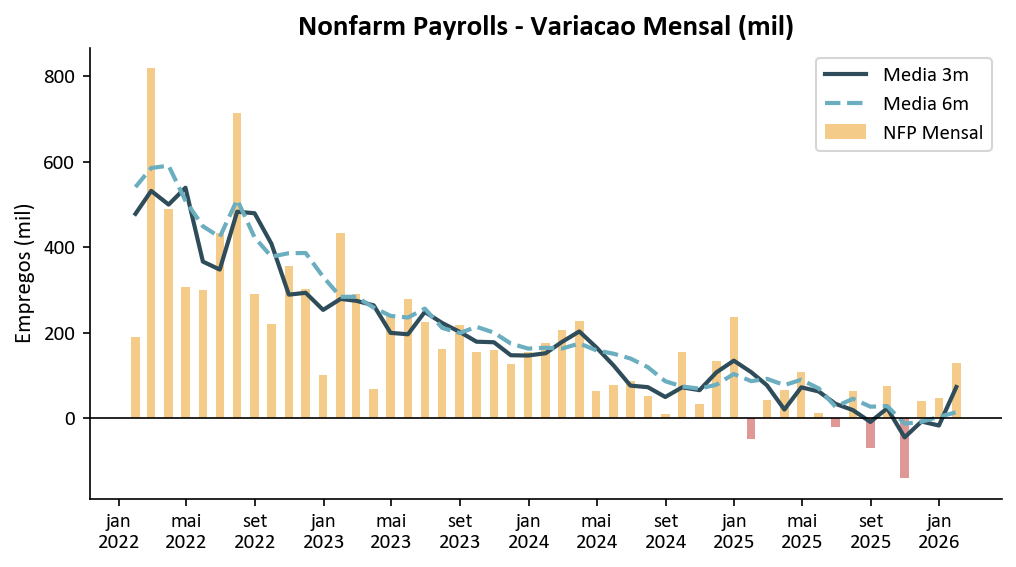

In [22]:
# Grafico: NFP com Medias Moveis (Word-optimized)
# Filtra dados pelo PLOT_START_DATE para o grafico
plot_data = payroll_with_ma[payroll_with_ma.index >= pd.to_datetime(PLOT_START_DATE)].copy()

fig, ax = plt.subplots(figsize=WORD_FIGSIZE, dpi=WORD_DPI)

# Barras para NFP mensal
colors = [COPOM[1] if v >= 0 else COPOM[5] for v in plot_data['NFP']]
ax.bar(plot_data.index, plot_data['NFP'], 
       color=colors, alpha=0.7, label='NFP Mensal', width=15)

# Linhas para medias moveis
ax.plot(plot_data.index, plot_data['NFP_MA3m'], 
        color=COPOM[0], linewidth=2, label='Media 3m')
ax.plot(plot_data.index, plot_data['NFP_MA6m'], 
        color=COPOM[2], linewidth=2, linestyle='--', label='Media 6m')

# Linha de referencia em zero
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

# Formatacao (Word-optimized sizes)
ax.set_title('Nonfarm Payrolls - Variacao Mensal (mil)', 
             fontsize=WORD_TITLE_SIZE, fontweight='bold')
ax.set_ylabel('Empregos (mil)', fontsize=WORD_LABEL_SIZE)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.tick_params(axis='both', labelsize=WORD_TICK_SIZE)
ax.legend(loc='upper right', fontsize=WORD_LEGEND_SIZE)
clean_axes(ax)

plt.tight_layout()

# Save Word-optimized version (convencao CLAUDE.md: output/ na raiz do projeto)
output_dir = project_root / 'output' / 'reports' / 'payroll'
output_dir.mkdir(parents=True, exist_ok=True)
save_chart_for_word(fig, output_dir / 'nfp_time_series_word.png')

# Also save original high-res version
plt.savefig(output_dir / 'nfp_time_series.png', 
            dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()

## 3. Dashboard do Mercado de Trabalho

Painel com os principais indicadores: Taxa de Desemprego, Participacao na Forca de Trabalho e Salarios.

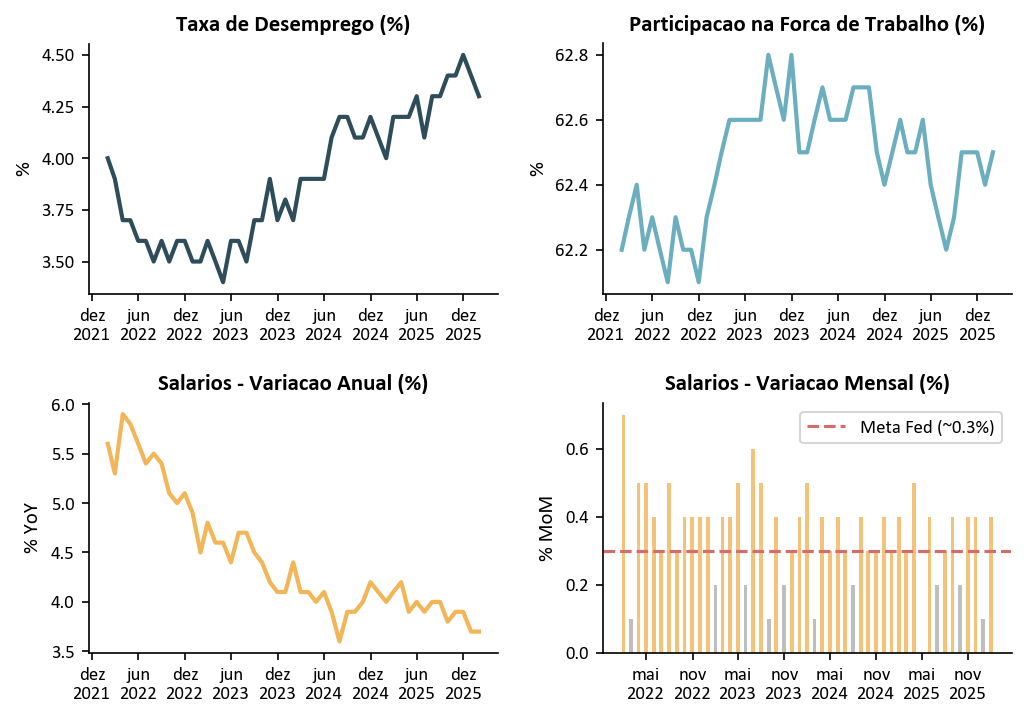

In [23]:
# Dashboard com 4 paineis (Word-optimized)
# Filtra dados pelo PLOT_START_DATE para o grafico
plot_data = payroll_data[payroll_data.index >= pd.to_datetime(PLOT_START_DATE)].copy()

fig, axes = plt.subplots(2, 2, figsize=WORD_FIGSIZE_DASHBOARD, dpi=WORD_DPI)

# 1. Taxa de Desemprego
ax1 = axes[0, 0]
if 'Unemployment' in plot_data.columns:
    ax1.plot(plot_data.index, plot_data['Unemployment'], 
             color=COPOM[0], linewidth=2)
ax1.set_title('Taxa de Desemprego (%)', fontsize=WORD_LABEL_SIZE, fontweight='bold')
ax1.set_ylabel('%', fontsize=WORD_TICK_SIZE)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.tick_params(axis='both', labelsize=WORD_TICK_SIZE - 1)
clean_axes(ax1)

# 2. Participacao na Forca de Trabalho
ax2 = axes[0, 1]
if 'LFPR' in plot_data.columns:
    ax2.plot(plot_data.index, plot_data['LFPR'], 
             color=COPOM[2], linewidth=2)
ax2.set_title('Participacao na Forca de Trabalho (%)', fontsize=WORD_LABEL_SIZE, fontweight='bold')
ax2.set_ylabel('%', fontsize=WORD_TICK_SIZE)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax2.tick_params(axis='both', labelsize=WORD_TICK_SIZE - 1)
clean_axes(ax2)

# 3. Salarios YoY
ax3 = axes[1, 0]
if 'AHE_YoY' in plot_data.columns:
    ax3.plot(plot_data.index, plot_data['AHE_YoY'], 
             color=COPOM[1], linewidth=2)
ax3.set_title('Salarios - Variacao Anual (%)', fontsize=WORD_LABEL_SIZE, fontweight='bold')
ax3.set_ylabel('% YoY', fontsize=WORD_TICK_SIZE)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax3.tick_params(axis='both', labelsize=WORD_TICK_SIZE - 1)
clean_axes(ax3)

# 4. Salarios MoM
ax4 = axes[1, 1]
if 'AHE_MoM' in plot_data.columns:
    colors = [COPOM[1] if v >= 0.3 else COPOM[9] for v in plot_data['AHE_MoM']]
    ax4.bar(plot_data.index, plot_data['AHE_MoM'], 
            color=colors, alpha=0.8, width=15)
    ax4.axhline(y=0.3, color=COPOM[5], linewidth=1.5, linestyle='--', 
                label='Meta Fed (~0.3%)')
ax4.set_title('Salarios - Variacao Mensal (%)', fontsize=WORD_LABEL_SIZE, fontweight='bold')
ax4.set_ylabel('% MoM', fontsize=WORD_TICK_SIZE)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax4.tick_params(axis='both', labelsize=WORD_TICK_SIZE - 1)
ax4.legend(loc='upper right', fontsize=WORD_TICK_SIZE - 1)
clean_axes(ax4)

plt.tight_layout()

# Save Word-optimized version (convencao CLAUDE.md: output/ na raiz do projeto)
output_dir = project_root / 'output' / 'reports' / 'payroll'
output_dir.mkdir(parents=True, exist_ok=True)
save_chart_for_word(fig, output_dir / 'labor_market_dashboard_word.png')

# Also save original high-res version
plt.savefig(output_dir / 'labor_market_dashboard.png', 
            dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()

## 4. Emprego por Setor (Industry Breakdown)

Variacao do emprego por setor da economia.

In [24]:
# Busca dados do BLS
industry_data = fetch_industry_breakdown()
print(f"Dados do BLS carregados: {len(industry_data)} setores")

Dados do BLS carregados: 38 setores


In [25]:
# Exibe tabela com breakdown
if industry_data is not None and len(industry_data) > 0:
    display(industry_data.style.format({'current_month': '{:.0f}', 
                                        'prior_month': '{:.0f}',
                                        'prior_year': '{:.0f}'}).set_caption('Emprego por Setor (mil)'))

,industry,level,prior_year,prior_month,current_month
0,Total nonfarm,0,-48,41,48
1,Total private,0,-76,72,64
2,Goods-producing,1,-32,25,-12
3,Mining and logging,1,0,-1,0
4,Construction,1,-12,36,-4
5,Manufacturing,1,-20,-10,-8
6,Durable goods,1,-17,-3,-2
7,Motor vehicles and parts,1,-12,-0,-1
8,Nondurable goods,1,-3,-7,-6
9,Private service-providing,1,-44,47,76


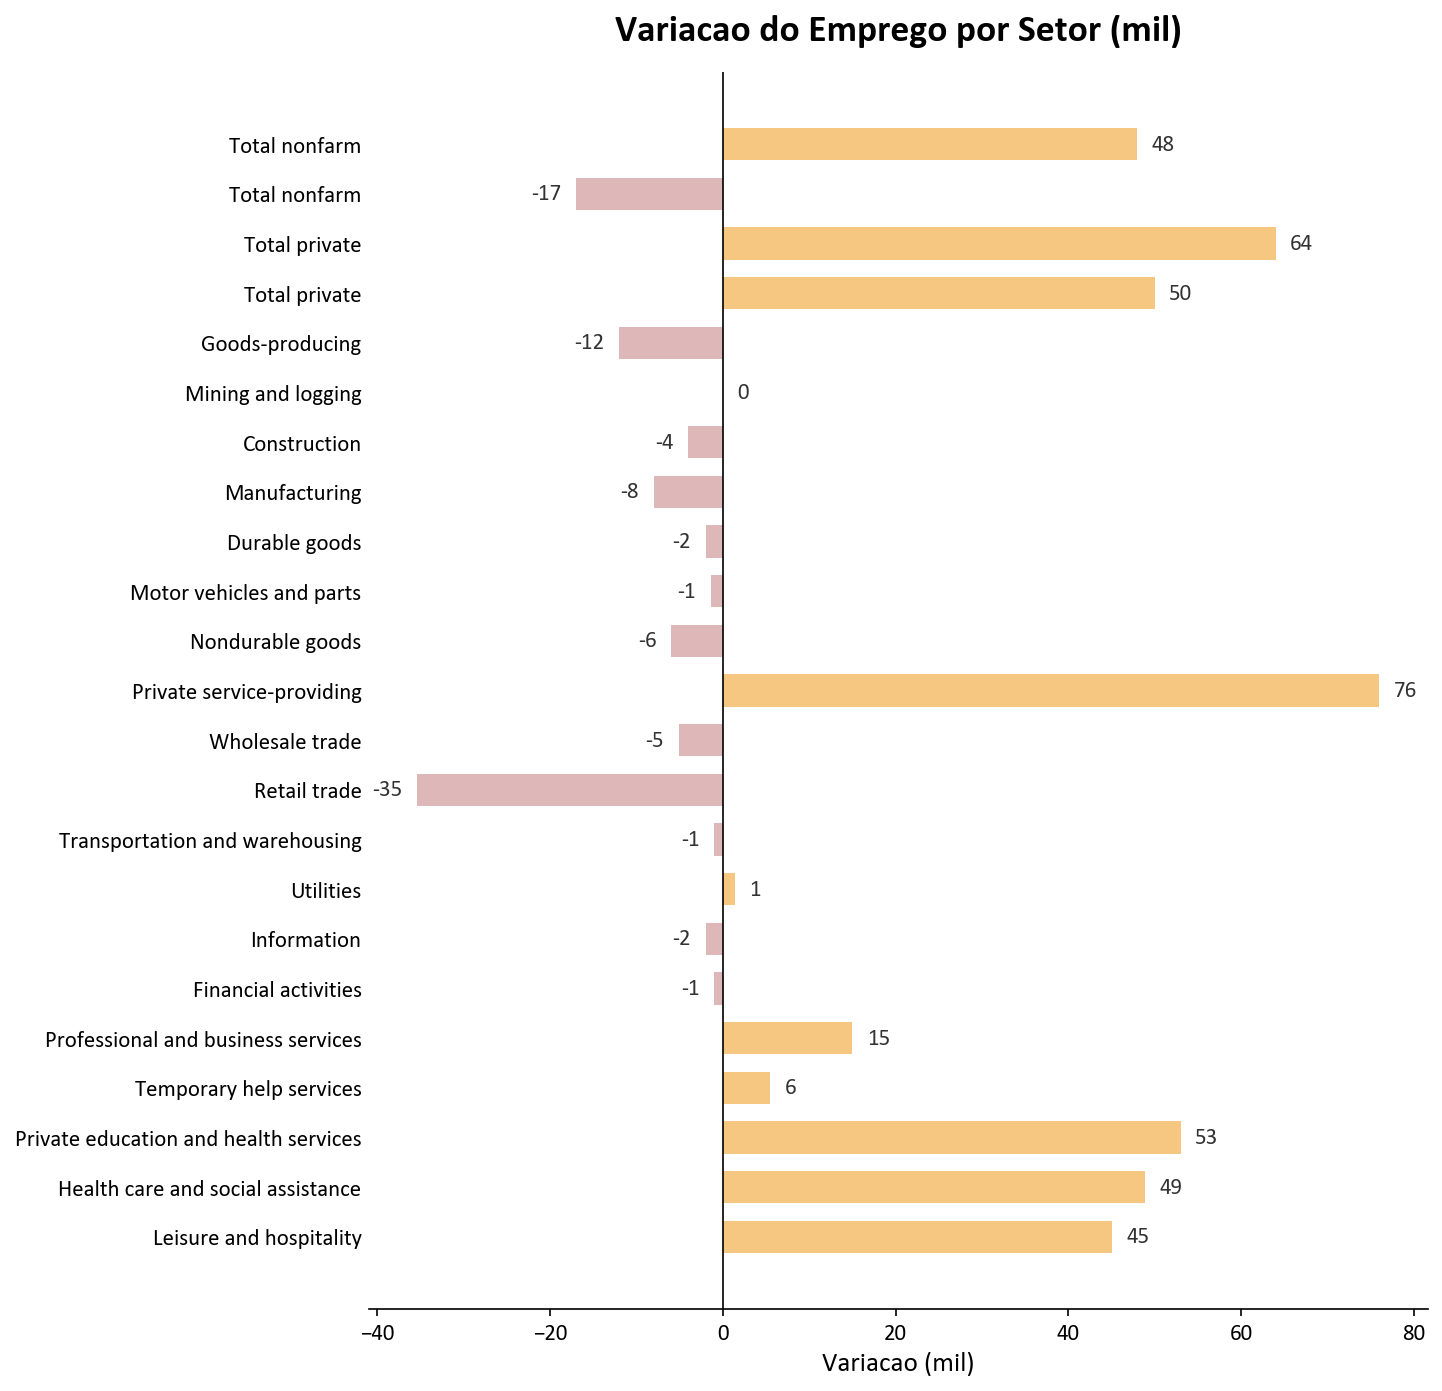

In [26]:
# Grafico: Barras horizontais por setor (Word-optimized)
if industry_data is not None and len(industry_data) > 0:
    # Whitelist dos 21 setores na ordem hierarquica do BLS
    INDUSTRY_ORDER = [
        'Total nonfarm',
        'Total private',
        'Goods-producing',
        'Mining and logging',
        'Construction',
        'Manufacturing',
        'Durable goods',
        'Motor vehicles and parts',
        'Nondurable goods',
        'Private service-providing',
        'Wholesale trade',
        'Retail trade',
        'Transportation and warehousing',
        'Utilities',
        'Information',
        'Financial activities',
        'Professional and business services',
        'Temporary help services',
        'Private education and health services',
        'Health care and social assistance',
        'Leisure and hospitality',
    ]

    plot_data = industry_data[
        industry_data['industry'].isin(INDUSTRY_ORDER)
    ].copy()
    plot_data = plot_data.dropna(subset=['current_month'])

    # Manter ordem hierarquica do BLS (invertida para matplotlib barh: bottom-to-top)
    industry_cat = pd.CategoricalDtype(categories=INDUSTRY_ORDER[::-1], ordered=True)
    plot_data['industry'] = plot_data['industry'].astype(industry_cat)
    plot_data = plot_data.sort_values('industry')
    
    if len(plot_data) > 0:
        # Adjust height based on number of sectors
        n_sectors = len(plot_data)
        fig_height = max(6.0, n_sectors * 0.42)
        
        fig, ax = plt.subplots(figsize=(10.0, fig_height), dpi=WORD_DPI)
        fig.patch.set_facecolor('white')
        ax.set_facecolor('white')
        
        # Cores: dourado para positivo, rosa empoeirado para negativo
        colors = [COPOM[1] if v >= 0 else '#D4A0A0' for v in plot_data['current_month']]
        
        y_pos = range(len(plot_data))
        ax.barh(y_pos, plot_data['current_month'], color=colors, alpha=0.75, height=0.65)
        
        # Labels
        ax.set_yticks(y_pos)
        ax.set_yticklabels(plot_data['industry'], fontsize=11)
        ax.tick_params(axis='y', length=0)
        ax.spines['left'].set_visible(False)
        ax.axvline(x=0, color='black', linewidth=0.8, zorder=2)
        
        # Adiciona valores nas barras
        x_range = plot_data['current_month'].max() - plot_data['current_month'].min()
        for i, (idx, row) in enumerate(plot_data.iterrows()):
            val = row['current_month']
            offset = max(1.0, x_range * 0.015) if val >= 0 else -max(1.0, x_range * 0.015)
            ha = 'left' if val >= 0 else 'right'
            ax.annotate(f'{val:.0f}', xy=(val + offset, i), 
                       va='center', ha=ha, fontsize=11, color='#333333')
        
        ax.set_title('Variacao do Emprego por Setor (mil)', 
                     fontsize=18, fontweight='bold', pad=15)
        ax.set_xlabel('Variacao (mil)', fontsize=13)
        ax.tick_params(axis='x', labelsize=11)
        clean_axes(ax)
        
        plt.tight_layout(pad=1.5)
        
        # Save Word-optimized version (convencao CLAUDE.md: output/ na raiz do projeto)
        output_dir = project_root / 'output' / 'reports' / 'payroll'
        output_dir.mkdir(parents=True, exist_ok=True)
        save_chart_for_word(fig, output_dir / 'industry_breakdown_word.png')
        
        # Also save original high-res version
        plt.savefig(output_dir / 'industry_breakdown.png', 
                    dpi=DPI, bbox_inches='tight', facecolor='white')
        plt.show()

## 5. Estatisticas e Tendencia

In [27]:
# Estatisticas do NFP
nfp_stats = calculate_period_stats(payroll_data, 'NFP')
trend = get_trend_assessment(payroll_data, 'NFP')

print("=" * 50)
print("ESTATISTICAS - NONFARM PAYROLLS")
print("=" * 50)
print(f"Media mensal:      {nfp_stats['mean']:.0f} mil")
print(f"Desvio padrao:     {nfp_stats['std']:.0f} mil")
print(f"Minimo:            {nfp_stats['min']:.0f} mil")
print(f"Maximo:            {nfp_stats['max']:.0f} mil")
print(f"Ultimo valor:      {nfp_stats['latest']:.0f} mil")
print(f"Observacoes:       {nfp_stats['count']}")
print(f"Tendencia:         {trend}")
print("=" * 50)

ESTATISTICAS - NONFARM PAYROLLS
Media mensal:      115 mil
Desvio padrao:     1052 mil
Minimo:            -20469 mil
Maximo:            4631 mil
Ultimo valor:      130 mil
Observacoes:       433
Tendencia:         Acelerando


## 6. Exportar Dados para Excel

Exporta os dados processados para um arquivo Excel atualizado.

In [28]:
# Exporta dados para Excel (convencao CLAUDE.md: output/ na raiz do projeto)
output_dir = project_root / 'output' / 'reports' / 'payroll'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f'payroll_analysis_{datetime.now().strftime("%Y%m%d")}.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    # Sheet 1: Serie historica com medias moveis
    payroll_with_ma.to_excel(writer, sheet_name='Serie Historica')
    
    # Sheet 2: Industry breakdown (se disponivel)
    if industry_data is not None and len(industry_data) > 0:
        industry_data.to_excel(writer, sheet_name='Breakdown Setorial', index=False)
    
    # Sheet 3: Resumo do release (se disponivel)
    if release_summary is not None:
        release_summary.to_excel(writer, sheet_name='Release Atual', index=False)

print(f"Dados exportados para: {output_path}")

Dados exportados para: e:\Github\marc3lom\py-bcb\output\reports\payroll\payroll_analysis_20260211.xlsx


---

**Notas:**
- Este notebook pode ser re-executado a cada release do Employment Situation Report
- Dados historicos do Bloomberg, breakdown setorial do BLS
- Graficos sao salvos automaticamente na pasta `output/`